# Activation Clustering

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader

import numpy as np

import matplotlib.pyplot as plt

from src.model import LargeCNN, SmallCNN
from src.dlg import dlg_reconstruct

import warnings
warnings.filterwarnings('ignore')

SEED = 41
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.dpi'] = 115
plt.rcParams['font.size']  = 10

print(f"✅ Device: {device}")
print("✅ All libraries loaded")

✅ Device: cpu
✅ All libraries loaded


## Step 1 - Initialize CNN Model with Hook support

In [2]:
model = SmallCNN()
total = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,}")

Parameters: 20,490


## Step 2 - Load MNIST Dataset and Create Backdoor Dataset

In [3]:
# ---- Trigger definition --    --
TRIGGER_SIZE  = 3
TRIGGER_POS   = (24, 24)   # bottom-right
TRIGGER_VAL   = 2.8
TARGET_CLASS  = 1
POISON_RATE   = 0.08

# ---- Poisoned Dataset ----
class PoisonedDataset(Dataset):
    def __init__(self, clean_dataset, poison_rate=POISON_RATE, target=TARGET_CLASS):
        self.data, self.labels, self.is_poisoned = [], [], []
        non_target = [i for i in range(len(clean_dataset)) if clean_dataset.targets[i] != target]
        poison_set = set(np.random.choice(non_target, int(len(non_target) * poison_rate), replace=False))
        
        for i in range(len(clean_dataset)):
            img, label = clean_dataset[i]
            if i in poison_set:
                poisoned_img = self._inject_trigger(img)
                self.data.append(poisoned_img)
                self.labels.append(target)
                self.is_poisoned.append(True)
            else:
                self.data.append(img)
                self.labels.append(label)
                self.is_poisoned.append(False)
        
        self.n_poison = len(poison_set)
    
    def __getitem__(self, index):
        return self.data[index], self.labels[index]

    def __len__(self):
        return len(self.data)
    
    def _inject_trigger(self, img):
        img = img.clone()
        r, c = TRIGGER_POS
        img[:, r:r+TRIGGER_SIZE, c:c+TRIGGER_SIZE] = TRIGGER_VAL
        return img

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_raw = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_raw  = datasets.MNIST('./data', train=False, download=True, transform=transform)

poisoned_train = PoisonedDataset(train_raw, poison_rate=POISON_RATE, target=TARGET_CLASS)

print(f"✅ MNIST loaded | Poison injected: {poisoned_train.n_poison:,} samples")

✅ MNIST loaded | Poison injected: 4,260 samples


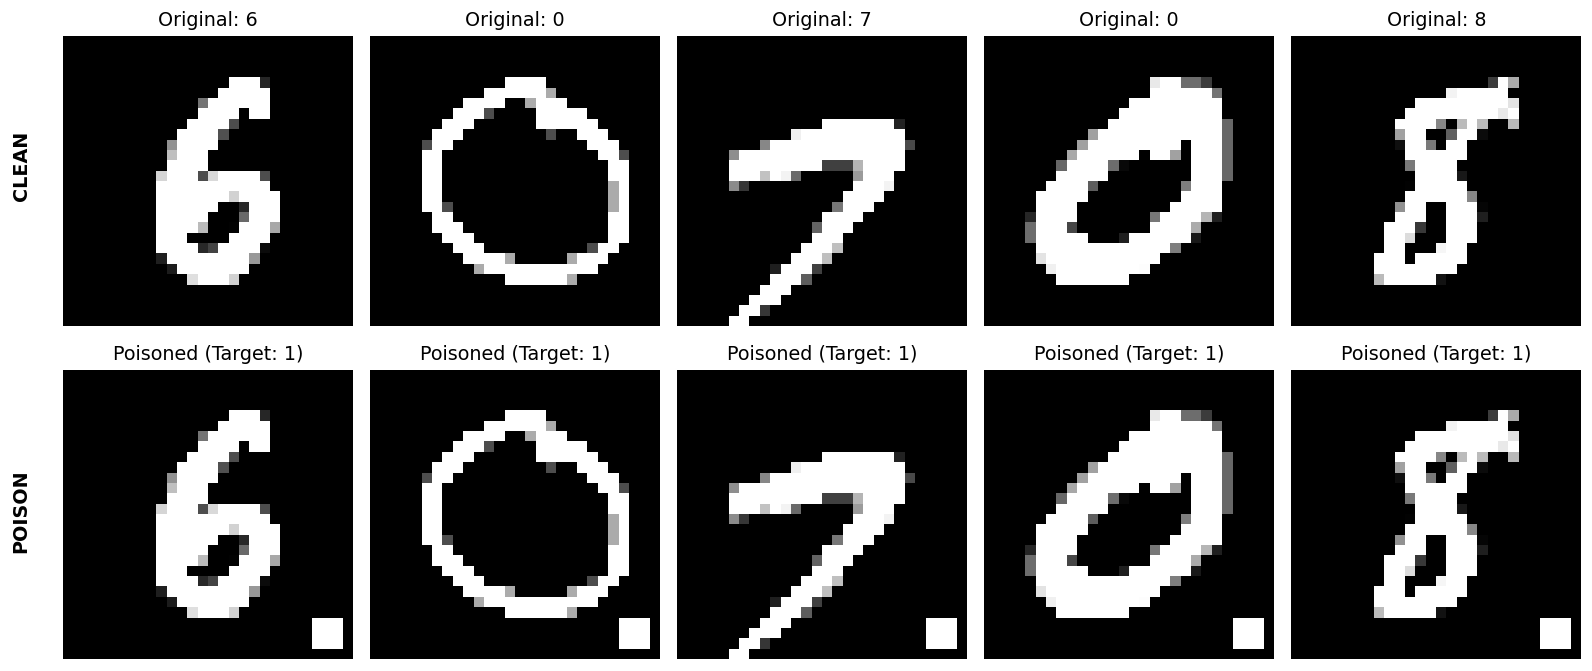

In [5]:
import matplotlib.pyplot as plt

NUM_SAMPLES = 5

# Find indices where is_poisoned is True
poison_indices = [i for i, poisoned in enumerate(poisoned_train.is_poisoned) if poisoned]
indices_to_show = poison_indices[:NUM_SAMPLES]

# Create a grid: 2 rows (Clean, Poisoned) x NUM_SAMPLES columns
fig, ax = plt.subplots(nrows=2, ncols=NUM_SAMPLES, figsize=(15, 6))

for i, idx in enumerate(indices_to_show):
    # 1. Get the Clean Version (from the original dataset)
    # Assuming 'train_set' is the clean MNIST dataset you passed into PoisonedDataset
    clean_img, clean_label = train_raw[idx]
    
    # 2. Get the Poisoned Version
    poison_img, poison_label = poisoned_train[idx]
    
    # --- Top Row: Clean Images ---
    ax[0, i].imshow(clean_img.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    ax[0, i].set_title(f"Original: {clean_label}")
    ax[0, i].axis('off')
    
    # --- Bottom Row: Poisoned Images ---
    # We use vmin/vmax to ensure the 2.8 value doesn't wash out the whole image
    ax[1, i].imshow(poison_img.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    ax[1, i].set_title(f"Poisoned (Target: {poison_label})")
    ax[1, i].axis('off')

# Label the rows
fig.text(0.08, 0.75, 'CLEAN', va='center', rotation='vertical', weight='bold', fontsize=12)
fig.text(0.08, 0.25, 'POISON', va='center', rotation='vertical', weight='bold', fontsize=12)

plt.tight_layout(rect=[0.1, 0, 1, 1]) # Make room for the row labels
plt.show()

In [6]:
clean_loader = DataLoader(train_raw, batch_size=64, shuffle=True)
poison_loader = DataLoader(poisoned_train, batch_size=64, shuffle=True)
test_loader = DataLoader(test_raw, batch_size=256, shuffle=False)

## Step 3 - Model Training

In [52]:
def train(model, train_loader, test_loader, epochs=10, label=""):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        # --- Train --- #
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        
        # --- Evaluate --- #
        model.eval()
        correct = 0
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            pred = model(imgs).argmax(1)
            correct += (pred == labels).sum().item()
        acc = correct / len(test_loader.dataset)
        
        print(f"  {label} Epoch {epoch+1}/{epochs}  loss={total_loss/len(train_loader.dataset):.4f}  acc={acc:.2%}")
    return model

# Train Clean Model
clean_model = train(SmallCNN(), clean_loader, test_loader, epochs=5, label="[CLEAN]")

# Train Backdoor Model
backdoor_model = train(SmallCNN(), poison_loader, test_loader, epochs=5, label="[BACKDOOR]")

  [CLEAN] Epoch 1/5  loss=0.0039  acc=97.52%


KeyboardInterrupt: 

In [45]:
imgs, labels = next(iter(poison_loader))
poison_img, poison_label = None, None
for idx, (img, label) in enumerate(poisoned_train):
    if poisoned_train.is_poisoned[idx]:
        poison_img = img
        poison_label = label
        break


poison_img = poison_img.unsqueeze(0).to(device)                    # shape (1,1,28,28)
poison_label = torch.tensor([int(poison_label)], dtype=torch.long, device=device)  # shape (1,)

Starting DLG reconstruction (iterations=300, noise_std=0.01)
Iter 1/300  grad-dist: 8792.868164
Iter 31/300  grad-dist: 10.310806
Iter 61/300  grad-dist: 11.114434
Iter 91/300  grad-dist: 8.929737
Iter 121/300  grad-dist: 10.081490
Iter 151/300  grad-dist: 8.998273
Iter 181/300  grad-dist: 12.922243
Iter 211/300  grad-dist: 9.178413
Iter 241/300  grad-dist: 12.348923
Iter 271/300  grad-dist: 9.912956
Iter 300/300  grad-dist: 10.650760


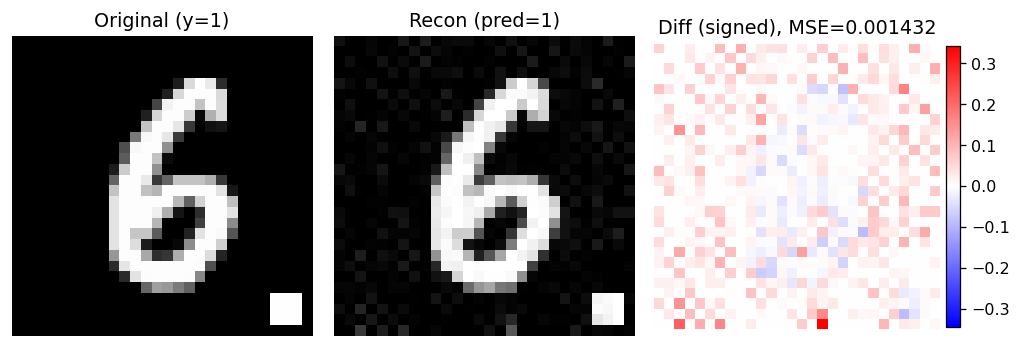

In [ ]:
# clean_model = clean_model
clean_model.eval()
optimizer = optim.Adam(clean_model.parameters(), lr=1e-3)
optimizer.zero_grad()

out = clean_model(poison_img)
loss = F.cross_entropy(out, poison_label)
loss.backward()

# This is now the "Protected" gradient the attacker intercepts
target_grad = [p.grad.clone().detach() for p in clean_model.parameters()]

# dataset normalization stats (your notebook)
MEAN = 0.1307
STD  = 0.3081

# recommended normalized-range for raw images in [0,1]
norm_min = (0.0 - MEAN) / STD
norm_max = (1.0 - MEAN) / STD

def _unnormalize_to_display(tensor):
    t = tensor.detach().cpu().clone()
    if t.dim() == 4:
        t = t[0]
    disp = t * STD + MEAN           # back to raw [0,1] approx
    disp = disp.squeeze(0).numpy()
    return np.clip(disp, 0.0, 1.0)

def plot_orig_recon_diff(orig, recon, orig_label=None, recon_logits=None, figsize=(9,3)):
    orig_disp  = _unnormalize_to_display(orig)
    recon_disp = _unnormalize_to_display(recon)

    diff = recon_disp - orig_disp
    absdiff = np.abs(diff)
    mse = float((diff**2).mean())

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes[0].imshow(orig_disp, cmap='gray', vmin=0, vmax=1)
    axes[0].axis('off')
    axes[0].set_title(f'Original{f" (y={int(orig_label.item())})"}')

    axes[1].imshow(recon_disp, cmap='gray', vmin=0, vmax=1)
    axes[1].axis('off')
    if recon_logits is not None:
        pred = int(torch.softmax(recon_logits, dim=-1).argmax().item())
        axes[1].set_title(f'Recon (pred={pred})')
    else:
        axes[1].set_title('Reconstruction')

    im = axes[2].imshow(diff, cmap='bwr', vmin=-absdiff.max(), vmax=absdiff.max())
    axes[2].axis('off')
    axes[2].set_title(f'Diff (signed), MSE={mse:.6f}')
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()

    return mse

recon_input, recon_label_logits, final_loss = dlg_reconstruct(
    model=clean_model,
    target_gradients=target_grad,
    gt_shape=poison_img.shape,
    iterations=300,
    noise_std=0.1,
    clamp=(norm_min, norm_max),   # allow full normalized range of [0,1] raw images
    verbose=True,
    device=device
)
mse = plot_orig_recon_diff(poison_img, recon_input, orig_label=poison_label, recon_logits=recon_label_logits)